# Assignment 1: Dataset Exploration & Problem Framing
### Dataset: World Happiness Report (2015-2019)

**Source:** https://www.kaggle.com/datasets/unsdsn/world-happiness

This notebook explores five years (2015-2019) of the World Happiness Report, frames a business
problem, determines the right Machine Learning approach, and documents key observations from the
data.


## 0. Load and Standardize the Data

Each year's file uses slightly different column names and includes/excludes different fields (a known quirk of this dataset), so we first standardize all five files onto a common schema before combining them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (9, 5)

raw = {y: pd.read_csv(f"{y}.csv") for y in [2015, 2016, 2017, 2018, 2019]}
for y, d in raw.items():
    print(y, d.shape, list(d.columns))

2015 (158, 12) ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
2016 (157, 13) ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
2017 (155, 12) ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']
2018 (156, 9) ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
2019 (156, 9) ['Overall rank', 'Country or regi

In [2]:
# Standardize each year onto a common set of columns:
# Country, Year, Happiness Rank, Happiness Score, GDP per Capita, Social Support,
# Health (Life Expectancy), Freedom, Generosity, Trust (Corruption)

def standardize(df, year):
    df = df.copy()
    rename_map = {
        'Country or region': 'Country',
        'Happiness Rank': 'Happiness Rank',
        'Happiness.Rank': 'Happiness Rank',
        'Overall rank': 'Happiness Rank',
        'Happiness Score': 'Happiness Score',
        'Happiness.Score': 'Happiness Score',
        'Score': 'Happiness Score',
        'Economy (GDP per Capita)': 'GDP per Capita',
        'Economy..GDP.per.Capita.': 'GDP per Capita',
        'GDP per capita': 'GDP per Capita',
        'Family': 'Social Support',
        'Social support': 'Social Support',
        'Health (Life Expectancy)': 'Health',
        'Health..Life.Expectancy.': 'Health',
        'Healthy life expectancy': 'Health',
        'Freedom': 'Freedom',
        'Freedom to make life choices': 'Freedom',
        'Trust (Government Corruption)': 'Trust',
        'Trust..Government.Corruption.': 'Trust',
        'Perceptions of corruption': 'Trust',
        'Generosity': 'Generosity',
    }
    df = df.rename(columns=rename_map)
    keep = ['Country', 'Happiness Rank', 'Happiness Score', 'GDP per Capita',
            'Social Support', 'Health', 'Freedom', 'Trust', 'Generosity']
    df = df[[c for c in keep if c in df.columns]]
    df['Year'] = year
    return df

standardized = [standardize(raw[y], y) for y in [2015, 2016, 2017, 2018, 2019]]
df = pd.concat(standardized, ignore_index=True)
df.head()

,Country,Happiness Rank,Happiness Score,GDP per Capita,Social Support,Health,Freedom,Trust,Generosity,Year
0,Switzerland,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2015
1,Iceland,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2015
2,Denmark,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2015
3,Norway,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2015
4,Canada,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2015


## 1. Understanding the Dataset and Its Purpose

The **World Happiness Report** ranks countries by self-reported well-being (the "Happiness Score",
based on Gallup World Poll surveys asking people to rate their own life on a 0-10 ladder) and
explains variation in that score using six factors: GDP per capita, social support, healthy life
expectancy, freedom to make life choices, generosity, and perceptions of corruption. This combined
dataset spans **five years (2015-2019)**, allowing both cross-country comparison and analysis of
happiness trends over time.

This kind of data is used by policymakers, researchers, and international organizations to
understand **what drives national well-being** and to track how it changes as economic and social
conditions shift.


In [3]:
print("Combined dataset shape (rows, columns):", df.shape)
df.info()

Combined dataset shape (rows, columns): (782, 10)
<class 'pandas.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          782 non-null    str    
 1   Happiness Rank   782 non-null    int64  
 2   Happiness Score  782 non-null    float64
 3   GDP per Capita   782 non-null    float64
 4   Social Support   782 non-null    float64
 5   Health           782 non-null    float64
 6   Freedom          782 non-null    float64
 7   Trust            781 non-null    float64
 8   Generosity       782 non-null    float64
 9   Year             782 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 61.2 KB


In [4]:
df.dtypes

Country                str
Happiness Rank       int64
Happiness Score    float64
GDP per Capita     float64
Social Support     float64
Health             float64
Freedom            float64
Trust              float64
Generosity         float64
Year                 int64
dtype: object

## 2. Business Problem(s)

1. **Drivers of happiness** — which factors (GDP, social support, health, freedom, trust,
   generosity) most strongly explain a country's happiness score, and how much does each contribute?
2. **Happiness score prediction** — given a country's socioeconomic indicators, predict its
   happiness score (useful for countries/years missing survey data, or "what-if" policy scenarios).
3. **Country clustering / peer grouping** — group countries into clusters with similar well-being
   profiles, beyond simple geographic region, to identify realistic peer countries for benchmarking.
4. **Trend analysis** — identify which countries or regions are improving or declining in happiness
   over the 2015-2019 period.

This notebook focuses on **Problem 2 (happiness score prediction)**, since the dataset has a clear
continuous target (`Happiness Score`) and a consistent set of numeric predictors across years.


## 3. Machine Learning Problem Framing

**Chosen approach: Regression (supervised learning)**

**Why regression, and not classification or clustering?**
- The target we care about, `Happiness Score`, is a **continuous numeric value** (roughly 0-10),
  not a category — which is the defining characteristic of a regression problem.
- Unlike clustering, we already have a well-defined outcome we want to predict for each row (each
  country-year), so this is **supervised** learning, not unsupervised.
- Classification would only apply if we first bucketed the score into categories (e.g., "high /
  medium / low happiness") — a valid alternative framing, but one that discards information
  compared to predicting the exact score.

**Summary of candidate framings:**

| Business Problem | ML Problem Type | Notes |
|---|---|---|
| Drivers of happiness | Regression (+ feature importance / coefficients) | Same target as below; focus is on interpretation, not just prediction |
| Happiness score prediction | Regression | Continuous target; chosen focus of this notebook |
| Country clustering | Clustering | No ground-truth "peer group" labels exist |
| Trend analysis | Time-series / descriptive analysis | Focused on change over `Year`, not a single predictive target |


## 4. Target Variable and Key Features

**Target variable:** `Happiness Score` — a continuous value (0-10) representing a country's
average self-reported well-being for a given year.

**Key features:**
- `GDP per Capita` — economic output per person (log-scaled GDP in the original survey methodology)
- `Social Support` (called "Family" in 2015-2016 data) — having someone to count on in times of trouble
- `Health` — healthy life expectancy at birth
- `Freedom` — freedom to make life choices
- `Trust` — perceptions of government/business corruption
- `Generosity` — reported charitable behavior
- `Country` / `Year` — identifiers, not predictive features themselves, but used for grouping and
  trend analysis

Note: `Happiness Rank` is **not** used as a feature since it's derived directly from the target
(rank is just the sort order of the score) — including it would leak the answer.


## 5. Basic Exploration with Pandas

### 5.1 Dataset shape

In [5]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Countries covered: {df['Country'].nunique()}")
print(f"Years covered: {sorted(df['Year'].unique())}")

Rows: 782
Columns: 10
Countries covered: 170
Years covered: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]


### 5.2 Data types

In [6]:
df.dtypes.to_frame(name="dtype")

,dtype
Country,str
Happiness Rank,int64
Happiness Score,float64
GDP per Capita,float64
Social Support,float64
Health,float64
Freedom,float64
Trust,float64
Generosity,float64
Year,int64


### 5.3 Missing values

In [7]:
missing = df.isna().sum().to_frame(name="missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing.sort_values("missing_count", ascending=False)

,missing_count,missing_pct
Trust,1,0.13
Country,0,0.00
Happiness Rank,0,0.00
Happiness Score,0,0.00
Social Support,0,0.00
GDP per Capita,0,0.00
Health,0,0.00
Freedom,0,0.00
Generosity,0,0.00
Year,0,0.00


In [8]:
# Which rows/years are missing Trust?
df[df["Trust"].isna()]

,Country,Happiness Rank,Happiness Score,GDP per Capita,Social Support,Health,Freedom,Trust,Generosity,Year
489,United Arab Emirates,20,6.774,2.096,0.776,0.67,0.284,NaN,0.186,2018


### 5.4 Summary statistics

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Happiness Rank,782.0,78.698210,45.182384,1.000,40.000000,79.000000,118.000000,158.000000
Happiness Score,782.0,5.379018,1.127456,2.693,4.509750,5.322000,6.189500,7.769000
GDP per Capita,782.0,0.916047,0.407340,0.000,0.606500,0.982205,1.236187,2.096000
Social Support,782.0,1.078392,0.329548,0.000,0.869363,1.124735,1.327250,1.644000
Health,782.0,0.612416,0.248309,0.000,0.440183,0.647310,0.808000,1.141000
Freedom,782.0,0.411091,0.152880,0.000,0.309768,0.431000,0.531000,0.724000
Trust,781.0,0.125436,0.105816,0.000,0.054000,0.091000,0.156030,0.551910
Generosity,782.0,0.218576,0.122321,0.000,0.130000,0.201982,0.278832,0.838075
Year,782.0,2016.993606,1.417364,2015.000,2016.000000,2017.000000,2018.000000,2019.000000


### 5.5 A closer look: top/bottom countries and score distribution over time

In [10]:
avg_by_country = df.groupby("Country")["Happiness Score"].mean().sort_values(ascending=False)
print("Top 10 happiest countries (avg 2015-2019):")
print(avg_by_country.head(10))
print("\nBottom 10 happiest countries (avg 2015-2019):")
print(avg_by_country.tail(10))

Top 10 happiest countries (avg 2015-2019):
Country
Denmark        7.5460
Norway         7.5410
Finland        7.5378
Switzerland    7.5114
Iceland        7.5110
Netherlands    7.4046
Canada         7.3506
Sweden         7.3192
New Zealand    7.3130
Australia      7.2762
Name: Happiness Score, dtype: float64

Bottom 10 happiest countries (avg 2015-2019):
Country
Madagascar                  3.74540
Yemen                       3.62580
Togo                        3.54420
Afghanistan                 3.51280
Tanzania                    3.46600
Rwanda                      3.43860
South Sudan                 3.38250
Syria                       3.29220
Central African Republic    3.13425
Burundi                     3.07900
Name: Happiness Score, dtype: float64


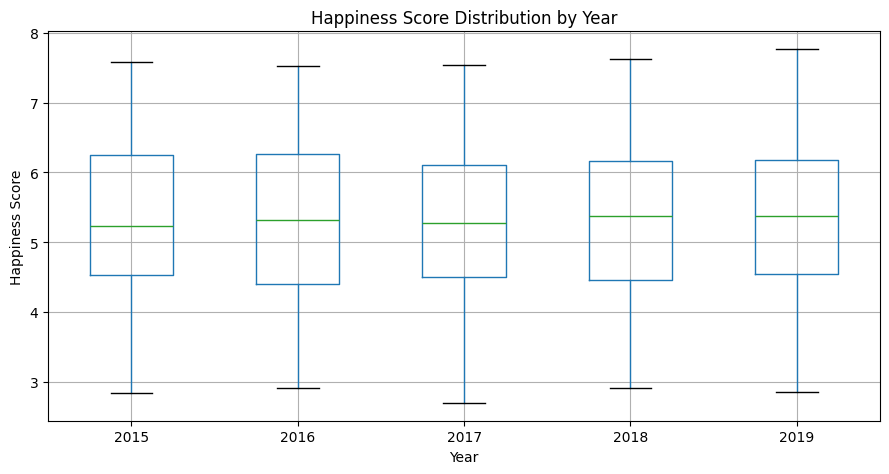

In [11]:
df.boxplot(column="Happiness Score", by="Year")
plt.title("Happiness Score Distribution by Year")
plt.suptitle("")
plt.ylabel("Happiness Score")
plt.tight_layout()
plt.show()

In [12]:
corr = df[["Happiness Score", "GDP per Capita", "Social Support", "Health",
           "Freedom", "Trust", "Generosity"]].corr()
corr["Happiness Score"].sort_values(ascending=False)

Happiness Score    1.000000
GDP per Capita     0.789284
Health             0.742456
Social Support     0.648799
Freedom            0.551258
Trust              0.398418
Generosity         0.137578
Name: Happiness Score, dtype: float64

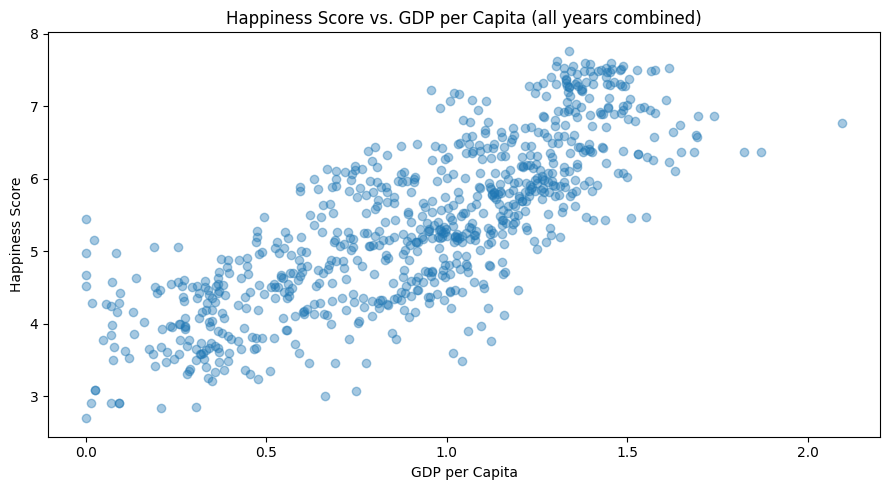

In [13]:
plt.scatter(df["GDP per Capita"], df["Happiness Score"], alpha=0.4)
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")
plt.title("Happiness Score vs. GDP per Capita (all years combined)")
plt.tight_layout()
plt.show()

## 6. Three Key Observations

1. **GDP per capita and health are the strongest single correlates of happiness, while generosity
   is by far the weakest.** Correlations with `Happiness Score` across all five years combined are:
   GDP per Capita (0.79), Health (0.74), Social Support (0.65), Freedom (0.55), Trust (0.40), and
   Generosity (only 0.14). Wealth and life expectancy track much more closely with self-reported
   well-being than how generous a country's population reports being.

2. **The `Trust` (perceptions of corruption) column has exactly one missing value**, for the United
   Arab Emirates in the 2018 file — everything else in the combined 782-row dataset is complete.
   It's a small gap, but it's exactly the kind of single silent `NaN` that can break a model
   training pipeline if there's no explicit handling (drop the row, or impute) for that column.

3. **The same small group of countries dominates the top of the ranking across all five years,
   and the same group of conflict/hardship-affected countries sits at the bottom.** Denmark,
   Norway, Finland, Switzerland, and Iceland are the five highest-averaging countries over
   2015-2019, while Burundi, the Central African Republic, Syria, South Sudan, and Rwanda are the
   five lowest. This persistence suggests happiness is driven more by structural, slow-changing
   national conditions than by short-term year-to-year shocks, at least over this five-year window.


## 7. Extending This Analysis (Next Steps)

- Fit a **multiple linear regression** (or a tree-based regressor like Random Forest) with
  `Happiness Score` as the target and the six factor columns as predictors; evaluate with
  train/test split and R² / RMSE.
- Compare **feature importances / coefficients** to quantify which factor matters most, controlling
  for the others (correlation alone doesn't account for overlap between correlated predictors like
  GDP and Health).
- Merge in `Year` as a feature or run the regression separately per year to see if the relationship
  between GDP and happiness has strengthened or weakened over time.
- As a follow-up **clustering** problem, group countries by their factor profiles (not just their
  score) to find peer groups that share similar strengths/weaknesses.
